# Fig 2.09

Metabolic network simulation

Using `Catalyst.jl` to simulate a metabolic network.

In [1]:
using OrdinaryDiffEq
using Catalyst
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    k1, 0 --> A
    k2, A --> B
    k3, A + B --> C + D
    k4, C --> 0
    k5, D --> 0
end

Model ##ReactionSystem#248:
Unknowns (4): see unknowns(##ReactionSystem#248)
  A(t)
  B(t)
  C(t)
  D(t)
Parameters (5): see parameters(##ReactionSystem#248)
  k1
  k2
  k3
  k4
  ⋮

Showing the differential equations in the reaction network

In [3]:
osys = convert(ODESystem, rn) |> complete
equations(osys)

4-element Vector{Symbolics.Equation}:
 Differential(t)(A(t)) ~ k1 - k2*A(t) - k3*B(t)*A(t)
 Differential(t)(B(t)) ~ k2*A(t) - k3*B(t)*A(t)
 Differential(t)(C(t)) ~ -k4*C(t) + k3*B(t)*A(t)
 Differential(t)(D(t)) ~ -k5*D(t) + k3*B(t)*A(t)

Solve the problem

In [4]:
ps = [:k1=>3., :k2=>2., :k3=>2.5, :k4=>3., :k5=>4.]
u0 = [:A=>0., :B=>0., :C=>0., :D=>0.]
tend = 10.
prob = ODEProblem(osys, u0, tend, ps)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 31-element Vector{Float64}:
  0.0
  9.999999999999999e-5
  0.0010999999999999998
  0.011099999999999997
  0.03427453254462915
  0.06522753353833287
  0.10153577459409753
  0.14533869701822555
  0.19788890020410435
  0.2619461233746949
  ⋮
  3.481141518838101
  4.1462374627542244
  4.984641398737613
  5.978883857784344
  6.9999177726334345
  7.954887766924096
  8.836082624890851
  9.672663483036162
 10.0
u: 31-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0]
 [0.00029997000199933764, 2.999799953754866e-8, 5.623912546644786e-16, 5.623800072204464e-16]
 [0.003296372652316679, 3.627331236355826e-6, 8.21805646090172e-12, 8.216249166279005e-12]
 [0.0329330063952576, 0.00036682535223159696, 8.356768013816538e-8, 8.338285321893432e-8]
 [0.09937122761544223, 0.0034375565665459152, 7.255794159499436e-6, 7.2066185248634404e-6]
 [0.1833655969433656, 0.01213116604059312, 8.93425388002502e-5, 8.820117939513288e-5]
 [0.2751746900149442, 0.028

Visual

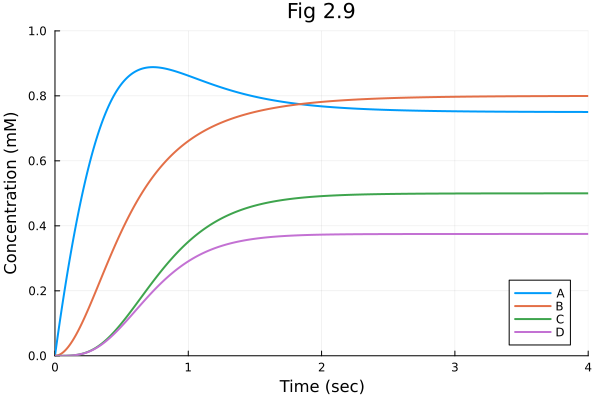

In [5]:
plot(sol, legend=:bottomright, title="Fig 2.9",
    xlims=(0., 4.), ylims=(0., 1.),
    xlabel="Time (sec)", ylabel="Concentration (mM)"
)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*